# Support Vector Machine (SVM)

## What is SVM?

**Support Vector Machine (SVM)** is a **Supervised Machine Learning Algorithm** used for both:

- Classification (**SVC - Support Vector Classifier**)
- Regression (**SVR - Support Vector Regressor**)

```text
              SVM
             /   \
          SVR     SVC
     (Regression) (Classification)
```

---

# When to use SVM?

SVM performs well when:

- Number of **features > number of samples**
- Dataset has many input features
- Text Classification
- Image Classification
- Face Recognition
- Spam Detection
- Medical Diagnosis

> **Note:** SVM generally works well for **small and medium-sized datasets**.

---

# Basic Idea of SVM

The main objective of SVM is to find the **best decision boundary (Hyperplane)** that separates different classes while maximizing the distance from the nearest data points.

```text
          Best Separation

      +      +      +      +
    +                     +

-------------------------------  (+ Margin)

===============================   Hyperplane

-------------------------------  (- Margin)

      ○      ○      ○      ○
         ○        ○
```

---

# Important Terminologies

## 1. Hyperplane

A **Hyperplane** is the decision boundary that separates two different classes.

For:

- 2D → Line
- 3D → Plane
- Higher Dimensions → Hyperplane

```text
     +     +     +

===================== Hyperplane

     ○     ○     ○
```

---

## 2. Support Vectors

Support Vectors are the **nearest data points to the hyperplane**.

They are the most important observations because they determine the position of the hyperplane.

```text
       +        ●

=======================

       ●        ○
```

**● = Support Vectors**

> During prediction, SVM mainly depends on these support vectors.

---

## 3. Margin

Margin is the **distance between the hyperplane and the nearest support vectors.**

```text
Support Vector
      ●
      |
      | Margin
      |
================ Hyperplane
```

### Rule

- Large Margin → Better Generalization
- Small Margin → Higher chance of Overfitting

---

# Scenario 1 : Linearly Separable Data

When data can be separated using a straight line, SVM creates the maximum margin hyperplane.

```text
          +    +    +

----------------------------

============================

----------------------------

      ○    ○    ○
```

This is called **Linear SVM**.

---

# Soft Margin

Unlike Perceptron, SVM allows a few misclassified data points.

This helps prevent overfitting.

```text
      +      +      +

========================

○      ○      x
```

Here **x** is a wrongly classified point.

---

# C Parameter (Regularization)

The **C parameter** controls the trade-off between:

- Maximum Margin
- Classification Error

---

## Small C

- Wide Margin
- Allows more mistakes
- Better Generalization
- High Bias
- Low Variance

```text
---------------- Wide Margin ----------------

================ Hyperplane

---------------- Wide Margin ----------------
```

---

## Large C

- Narrow Margin
- Allows fewer mistakes
- Fits training data closely
- Low Bias
- High Variance
- Can Overfit

```text
------ Narrow Margin ------

======= Hyperplane =======

------ Narrow Margin ------
```

### Common Values

```python
C = [0.01, 0.1, 1, 10, 100]
```

---

# Scenario 2 : Non-Linearly Separable Data

Sometimes data cannot be separated using a straight line.

```text
      ○ ○ ○
    ○      ○

      × × ×
    ×      ×
```

In this case SVM uses the **Kernel Trick**.

---

# Kernel Trick

Kernel transforms data into a **higher-dimensional space**, making it easier to separate.

```text
Original Data

○ ○ ○
  × × ×

        ↓ Kernel

Higher Dimension

Plane 1
○ ○ ○

Plane 2
× × ×
```

---

# Types of Kernels

## 1. Linear Kernel

Used for linearly separable data.

```python
kernel='linear'
```

---

## 2. Polynomial Kernel

Creates curved decision boundaries.

```python
kernel='poly'
```

Suitable for moderately complex datasets.

---

## 3. RBF (Radial Basis Function)

**Default Kernel**

```python
kernel='rbf'
```

- Handles complex datasets
- Most commonly used
- Produces non-linear decision boundaries

---

## 4. Sigmoid Kernel

Works similarly to the sigmoid activation function used in neural networks.

```python
kernel='sigmoid'
```

Used less frequently.

---

# Prediction Formula

SVM predicts using the equation:

\[
f(x)=w^Tx+b
\]

Where:

- **w** → Weight Vector
- **x** → Input Features
- **b** → Bias

The sign of the output determines the predicted class.

---

# Workflow of SVM

```text
Training Data
      │
      ▼
Choose Kernel
      │
      ▼
Find Support Vectors
      │
      ▼
Create Maximum Margin Hyperplane
      │
      ▼
Train Model
      │
      ▼
Prediction
```

---

# Advantages

- Works well with high-dimensional data
- Good for both Classification and Regression
- Effective on small and medium datasets
- Handles non-linear data using kernels
- Good generalization
- Memory efficient (uses only support vectors)

---

# Disadvantages

- Slow on very large datasets
- Training takes more time
- Sensitive to parameter tuning
- Scaling is required
- Difficult to interpret

---

# Feature Scaling in SVM

Since SVM is **distance-based**, scaling is very important.

Common Scalers:

- StandardScaler
- MinMaxScaler
- RobustScaler

Without scaling, features with larger values dominate the decision boundary.

---

# Syntax

```python
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)
```

---

# Real-Life Applications

- Face Recognition
- Spam Detection
- Text Classification
- Image Classification
- Medical Diagnosis
- Handwriting Recognition
- Bioinformatics
- Fraud Detection

---

# Interview Points

- SVM is a **Supervised Learning Algorithm**.
- Used for **Classification (SVC)** and **Regression (SVR)**.
- Creates the **Maximum Margin Hyperplane**.
- Uses **Support Vectors** to define the decision boundary.
- Uses the **Kernel Trick** for non-linear datasets.
- **RBF** is the default kernel.
- **C** controls the trade-off between margin size and classification error.
- Requires **Feature Scaling**.
- Best suited for **small to medium datasets** with many features.

---

# Complete SVM Summary

```text
                 Support Vector Machine

                        │
        ┌───────────────┴───────────────┐
        │                               │
      SVR                             SVC
 (Regression)                  (Classification)

                        │
                Find Hyperplane
                        │
                Maximum Margin
                        │
          Support Vectors determine boundary
                        │
      ┌─────────────────┴─────────────────┐
      │                                   │
Linear Data                      Non-linear Data
      │                                   │
Linear Kernel                Kernel Trick (RBF/Poly)
      │                                   │
                Prediction
```

## Implementation of SVC 

In [14]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

In [15]:
df = pd.read_csv("../datasets/titanic.csv")

In [16]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [17]:
df.drop(columns = ['pclass','name','ticket','cabin'], inplace = True)

In [18]:
df.isna().sum()

sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

In [20]:
df['age'] = df['age'].fillna(df['age'].median())

In [21]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [23]:
x = df.drop(columns='survived')
y = df.survived

In [24]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state=42,train_size=0.2)

In [25]:
num_cols = x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

/var/folders/zx/4wml1k7n6ml37j348fx1w4400000gn/T/ipykernel_28390/3270294241.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols=x.select_dtypes(include='object').columns


In [26]:
obj_cols

Index(['sex', 'embarked'], dtype='str')

<Axes: >

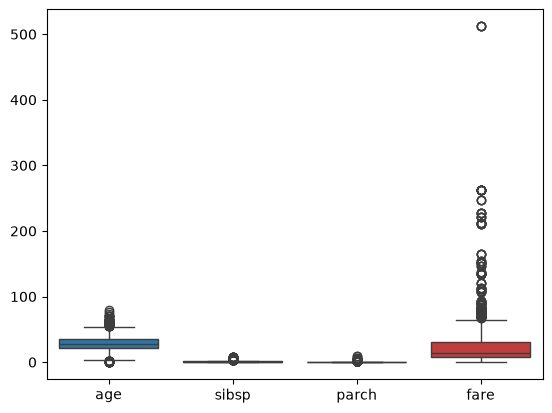

In [27]:
sns.boxplot(x[num_cols])

In [28]:
x[obj_cols].nunique()

sex         2
embarked    3
dtype: int64

In [29]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaling',RobustScaler(),num_cols),
        ('onehotencoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),
                obj_cols)
    ],remainder="passthrough"
)

In [30]:
pipeline = Pipeline(
    steps=[("preprocessing",preprocessing),
          ('model',SVC(random_state=42))
          ]
        )

In [31]:
grid_search_cv=GridSearchCV(
    estimator=pipeline,
    param_grid={
        'model__C':[0.01,0.1,1.0,10,100],
        'model__kernel':['linear','rbf','poly','sigmoid']
    },
    verbose=10,
    n_jobs=-1 
)

In [32]:
grid_search_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5; 2/20] START model__C=0.01, model__kernel=rbf...........................
[CV 5/5; 1/20] START model__C=0.01, model__kernel=linear........................
[CV 4/5; 1/20] START model__C=0.01, model__kernel=linear........................
[CV 1/5; 1/20] START model__C=0.01, model__kernel=linear........................
[CV 2/5; 1/20] START model__C=0.01, model__kernel=linear........................
[CV 3/5; 1/20] START model__C=0.01, model__kernel=linear........................
[CV 2/5; 2/20] START model__C=0.01, model__kernel=rbf...........................
[CV 3/5; 2/20] START model__C=0.01, model__kernel=rbf...........................
[CV 1/5; 1/20] END model__C=0.01, model__kernel=linear;, score=0.623 total time=   0.0s
[CV 3/5; 1/20] END model__C=0.01, model__kernel=linear;, score=0.615 total time=   0.0s
[CV 5/5; 1/20] END model__C=0.01, model__kernel=linear;, score=0.596 total time=   0.1s
[CV 1/5; 2/20] END model__

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear', 'rbf', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In all

In [33]:
grid_search_cv.best_estimator_ # It will return the best model/estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['sex','age','sibsp','parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

In [34]:
grid_search_cv.best_params_ # it will return the best parameter values

{'model__C': 100, 'model__kernel': 'rbf'}

In [35]:
grid_search_cv.cv_results_

{'mean_fit_time': array([0.02851124, 0.01654716, 0.0069056 , 0.0104044 , 0.00771279,
        0.00711474, 0.00647521, 0.00467362, 0.01068563, 0.00921497,
        0.01711574, 0.01064482, 0.00850897, 0.01137199, 0.01371984,
        0.01022525, 0.02411523, 0.00883627, 0.01390295, 0.0053144 ]),
 'std_fit_time': array([0.01002123, 0.0086338 , 0.00292233, 0.00600958, 0.00525546,
        0.00268769, 0.0022044 , 0.00055437, 0.00208561, 0.0050958 ,
        0.00788744, 0.00512424, 0.00442057, 0.00456416, 0.00719464,
        0.00530894, 0.01125377, 0.00283686, 0.00235474, 0.00138225]),
 'mean_score_time': array([0.04873586, 0.05662608, 0.00367618, 0.00522513, 0.0026876 ,
        0.00271559, 0.00223026, 0.00501699, 0.00459628, 0.00823822,
        0.00319862, 0.00273428, 0.00239196, 0.00709887, 0.00545831,
        0.00551896, 0.00257068, 0.00321622, 0.00315447, 0.0018394 ]),
 'std_score_time': array([0.03660651, 0.04065926, 0.00178281, 0.00523511, 0.00101665,
        0.00119435, 0.00045897, 0.005946

In [36]:
results = pd.DataFrame(grid_search_cv.cv_results_) 

In [ ]:
# results

In [37]:
results.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
17,0.008836,0.002837,0.003216,0.001276,100.00,rbf,"{'model__C': 100, 'model__kernel': 'rbf'}",0.735849,0.730769,0.788462,0.730769,0.750000,0.747170,0.021813,1
13,0.011372,0.004564,0.007099,0.005555,10.00,rbf,"{'model__C': 10, 'model__kernel': 'rbf'}",0.754717,0.711538,0.750000,0.750000,0.692308,0.731713,0.025131,2
18,0.013903,0.002355,0.003154,0.000444,100.00,poly,"{'model__C': 100, 'model__kernel': 'poly'}",0.716981,0.730769,0.730769,0.788462,0.653846,0.724165,0.042936,3
9,0.009215,0.005096,0.008238,0.008936,1.00,rbf,"{'model__C': 1.0, 'model__kernel': 'rbf'}",0.716981,0.692308,0.750000,0.769231,0.673077,0.720319,0.035499,4
16,0.024115,0.011254,0.002571,0.000762,100.00,linear,"{'model__C': 100, 'model__kernel': 'linear'}",0.679245,0.711538,0.769231,0.711538,0.673077,0.708926,0.034107,5
8,0.010686,0.002086,0.004596,0.003490,1.00,linear,"{'model__C': 1.0, 'model__kernel': 'linear'}",0.679245,0.711538,0.769231,0.711538,0.673077,0.708926,0.034107,5
12,0.008509,0.004421,0.002392,0.000606,10.00,linear,"{'model__C': 10, 'model__kernel': 'linear'}",0.679245,0.711538,0.769231,0.711538,0.673077,0.708926,0.034107,5
14,0.013720,0.007195,0.005458,0.004354,10.00,poly,"{'model__C': 10, 'model__kernel': 'poly'}",0.679245,0.750000,0.634615,0.769231,0.692308,0.705080,0.048845,8
4,0.007713,0.005255,0.002688,0.001017,0.10,linear,"{'model__C': 0.1, 'model__kernel': 'linear'}",0.660377,0.711538,0.769231,0.711538,0.634615,0.697460,0.046630,9
10,0.017116,0.007887,0.003199,0.001209,1.00,poly,"{'model__C': 1.0, 'model__kernel': 'poly'}",0.698113,0.769231,0.653846,0.711538,0.653846,0.697315,0.042788,10


In [38]:
grid_search_cv.predict(xtrain)

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0])